<a href="https://colab.research.google.com/github/yanaguntikarmeesal/used_phone_price_estimation/blob/main/phone_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("used_phone.csv")

In [ ]:
df

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price,resale_price
0,Samsung,Galaxy A55 5G,8,256,Like New,61,2,39999,17567
1,Oppo,OPPO A58 5G,6,128,Fair,69,1,13999,5216
2,OnePlus,OnePlus Nord N30 SE 5G,4,128,Like New,69,1,13999,7824
3,Redmi,POCO X5 Pro 5G,6,128,Fair,87,3,20999,7673
4,Realme,Realme Narzo 60x 5G,6,128,Fair,82,1,12999,5755
...,...,...,...,...,...,...,...,...,...
4995,Motorola,Motorola Edge 30 Ultra,12,256,Fair,77,1,49999,20789
4996,OnePlus,OnePlus 10R 5G,8,128,Fair,55,4,32999,6533
4997,Vivo,Vivo Y16,3,64,Like New,88,3,8999,4989
4998,Redmi,Redmi A3,3,64,Good,76,2,6999,3191


In [ ]:
df.shape

(5000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   brand           5000 non-null   object
 1   model           5000 non-null   object
 2   ram_gb          5000 non-null   int64 
 3   storage_gb      5000 non-null   int64 
 4   condition       5000 non-null   object
 5   battery_health  5000 non-null   int64 
 6   age_years       5000 non-null   int64 
 7   original_price  5000 non-null   int64 
 8   resale_price    5000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 351.7+ KB


In [ ]:
df.isnull().sum()

,0
brand,0
model,0
ram_gb,0
storage_gb,0
condition,0
battery_health,0
age_years,0
original_price,0
resale_price,0


In [ ]:
df.duplicated().sum()

np.int64(99)

In [ ]:
df = df.drop_duplicates()
df = df.reset_index(drop=True) # 0,1,2,3,4,5

In [ ]:
df.shape

(4901, 9)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price,resale_price
0,Samsung,Galaxy A55 5G,8,256,Like New,61,2,39999,17567
1,Oppo,OPPO A58 5G,6,128,Fair,69,1,13999,5216
2,OnePlus,OnePlus Nord N30 SE 5G,4,128,Like New,69,1,13999,7824
3,Redmi,POCO X5 Pro 5G,6,128,Fair,87,3,20999,7673
4,Realme,Realme Narzo 60x 5G,6,128,Fair,82,1,12999,5755


# object data converted into numerical with sklearn labelencoder
1. brand
2. model
3. condition

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le_brand = LabelEncoder() # instead
le_model = LabelEncoder()
le_condition = LabelEncoder()

In [ ]:
df["brand"] = le_brand.fit_transform(df["brand"])
df["model"] = le_model.fit_transform(df["model"])
df["condition"] = le_condition.fit_transform(df["condition"])

In [ ]:
df['brand']

,brand
0,7
1,4
2,3
3,6
4,5
...,...
4896,2
4897,3
4898,8
4899,6


In [ ]:
df["model"]

,model
0,8
1,54
2,79
3,84
4,103
...,...
4896,27
4897,70
4898,127
4899,111


In [ ]:
df["condition"]

,condition
0,2
1,0
2,2
3,0
4,0
...,...
4896,0
4897,0
4898,2
4899,1


In [ ]:
df.head()

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price,resale_price
0,7,8,8,256,2,61,2,39999,17567
1,4,54,6,128,0,69,1,13999,5216
2,3,79,4,128,2,69,1,13999,7824
3,6,84,6,128,0,87,3,20999,7673
4,5,103,6,128,0,82,1,12999,5755


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4901 entries, 0 to 4900
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   brand           4901 non-null   int64
 1   model           4901 non-null   int64
 2   ram_gb          4901 non-null   int64
 3   storage_gb      4901 non-null   int64
 4   condition       4901 non-null   int64
 5   battery_health  4901 non-null   int64
 6   age_years       4901 non-null   int64
 7   original_price  4901 non-null   int64
 8   resale_price    4901 non-null   int64
dtypes: int64(9)
memory usage: 344.7 KB


# Divided into independent & depending variable

In [ ]:
x = df.drop("resale_price", axis=1)
y = df["resale_price"]

In [ ]:
x.head(2)

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price
0,7,8,8,256,2,61,2,39999
1,4,54,6,128,0,69,1,13999


In [ ]:
y.head(2)

,resale_price
0,17567
1,5216


# Train Test split





In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print("The x train shape  : ", x_train.shape)
print("The x test shape   : ", x_test.shape)
print("The y train shape  : ", y_train.shape)
print("The y test shape   : ", y_test.shape)

The x train shape  :  (3920, 8)
The x test shape   :  (981, 8)
The y train shape  :  (3920,)
The y test shape   :  (981,)


# Training The MOdel Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
)

In [ ]:
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(x_test)
y_pred

array([20864.68,  5350.13,  3147.82,  1967.11,  4346.66, 36262.49,
       58638.83, 10017.5 , 19818.79, 30406.05, 73677.26,  8516.37,
        7531.76, 13978.43,  3380.54, 18045.56, 14466.85,  3556.2 ,
        4132.68,  8008.64,  6799.01,  3645.39,  3788.13, 49811.89,
        4417.74, 10316.08,  2990.01, 29529.15,  7733.97,  7026.38,
        4719.92,  8771.24,  9847.35, 19982.12, 24623.7 , 17128.5 ,
        6705.62,  4067.26,  5214.48,  1801.51,  2578.76,  7627.59,
        3692.45, 17688.28,  4112.05, 10364.88,  6221.39,  8917.09,
       75046.91,  2293.81, 24050.88, 44810.88, 12073.62, 28256.35,
        2236.32,  1493.62, 13868.58, 17710.68, 15962.51, 12210.76,
       26272.76,  7732.4 ,  6903.4 , 23647.13,  2631.38,  3763.32,
       15723.52,  8655.96,  7835.6 ,  3944.43,  7166.38,  5093.12,
       12451.75,  3226.31, 28318.73,  7416.26,  3168.96, 22708.41,
       30158.01, 56934.95,  2684.05,  1798.97,  4545.9 ,  3834.72,
        5831.46, 15832.35,  2988.44, 24746.47,  2670.  , 38672

# Performance Matrix

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("The R2 Score : ", r2)
print("The MAE Score : ", mae)
print("The MSE Score : ", mse)
print("The RMSE Score : ", rmse)

The R2 Score :  0.9872939706458711
The MAE Score :  758.3131090723751
The MSE Score :  3051339.050432416
The RMSE Score :  1746.808246612208


In [ ]:
df.head()

,brand,model,ram_gb,storage_gb,condition,battery_health,age_years,original_price,resale_price
0,7,8,8,256,2,61,2,39999,17567
1,4,54,6,128,0,69,1,13999,5216
2,3,79,4,128,2,69,1,13999,7824
3,6,84,6,128,0,87,3,20999,7673
4,5,103,6,128,0,82,1,12999,5755


In [ ]:
model.predict([[7,8,8,256,2,61,2,39999 ]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([17398.04])

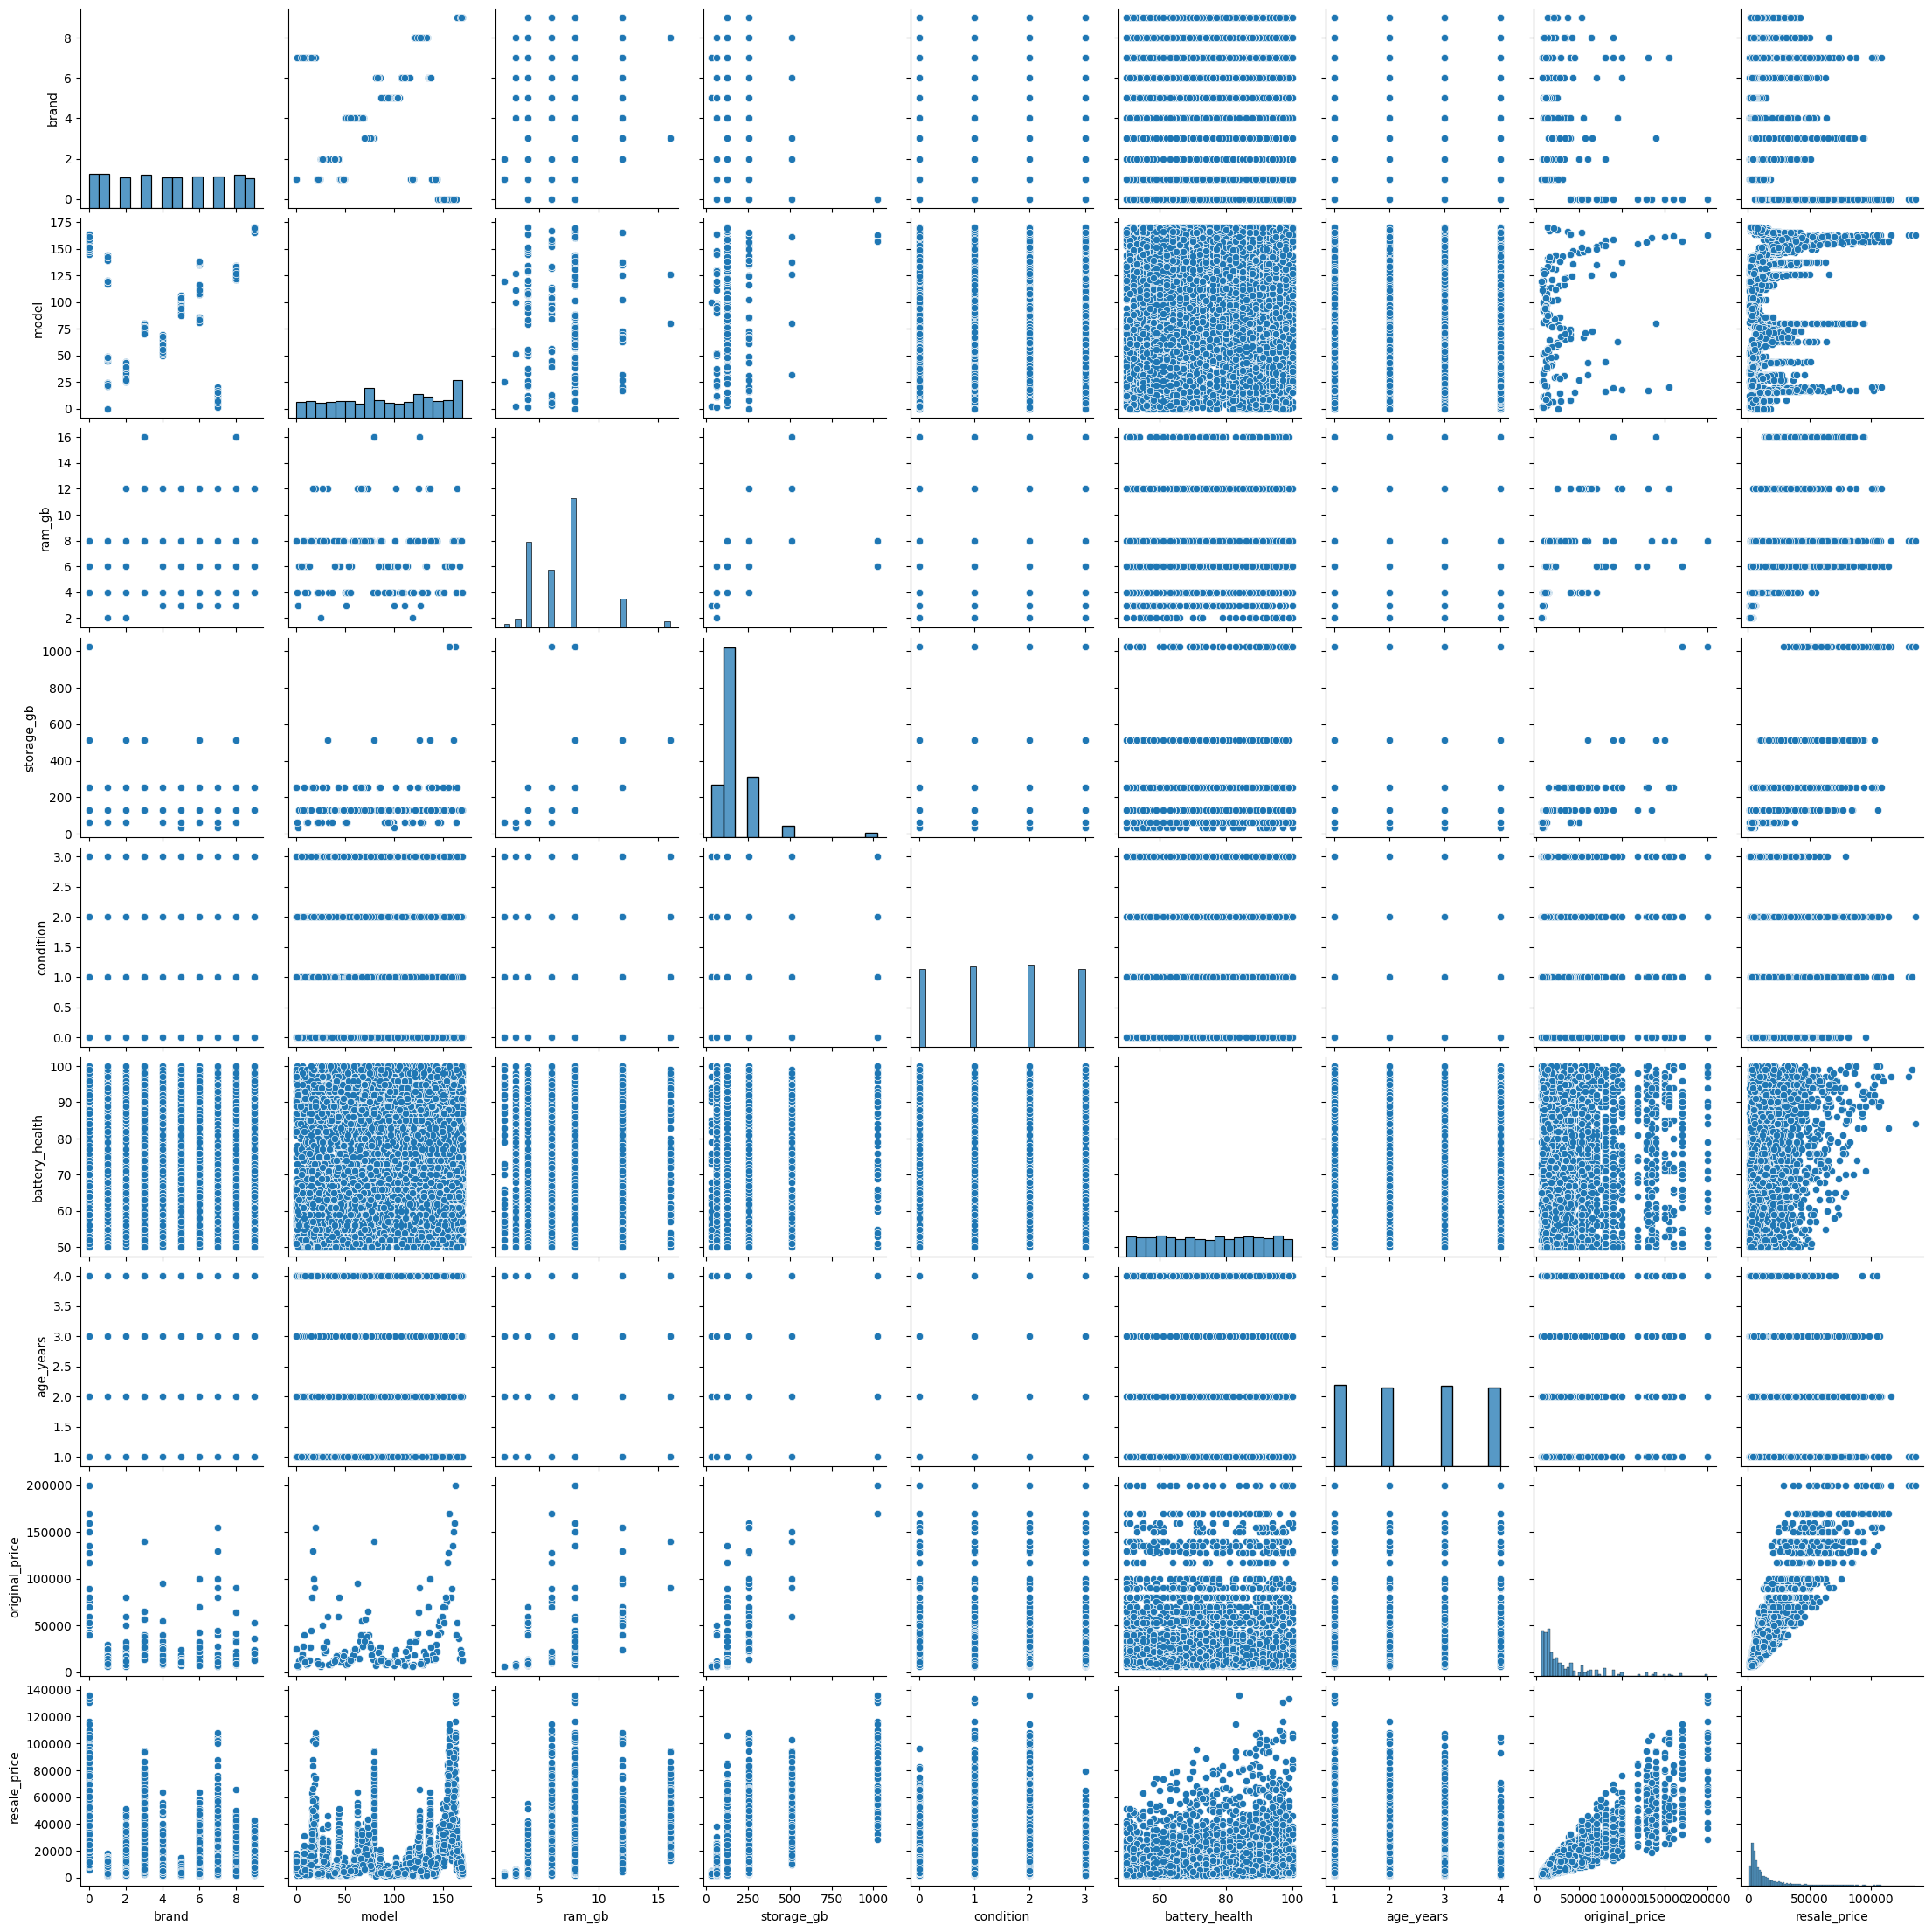

In [ ]:
# Affect resale_price based on data
import seaborn as sns
sns.pairplot(df)

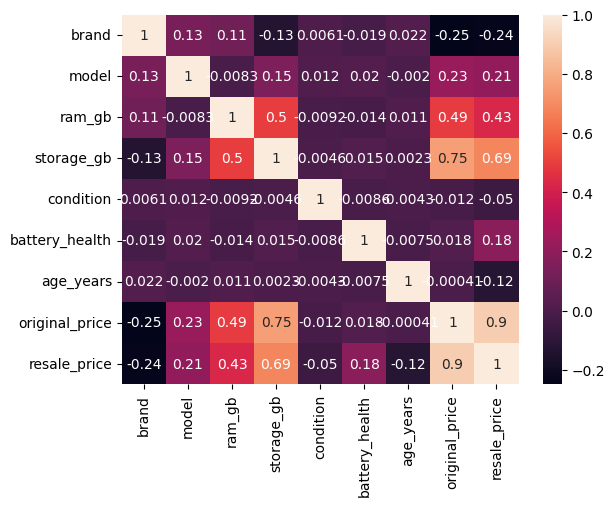

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.corr(), annot=True)
plt.show()

# pickle

In [ ]:
import pickle
with open("model_phone.pkl", "wb") as f:
    pickle.dump(model, f)

# vs code py file streamlit

In [ ]:
import streamlit as st
import pandas as pd
import pickle

# Load the model
model = pickle.load(open('model_phone.pkl', 'rb'))


df = pd.read_csv("used_phone.csv")


brand_model_map = df.groupby("brand")["model"].unique().to_dict()

brand_list = list(brand_model_map.keys())

st.title("phone price prediction ☎️📳")

st.sidebar.header("Enter phone Details")

selected_brand = st.sidebar.selectbox("Select Brand",brand_list)

selected_model = st.sidebar.selectbox("Select Model", brand_model_map[selected_brand])

ram = st.sidebar.selectbox("Ram(GB)",sorted(df["ram_gb"].unique()))

storage = st.sidebar.selectbox("Storage(GB)",sorted(df["storage_gb"].unique()))

condition = st.sidebar.selectbox("Condition",sorted(df["condition"].unique()))

battery_health = st.sidebar.slider("Battery Health(%)",50,100,80)

age = st.sidebar.slider("Age of the phone(years)",0,10,2)

original_price = st.sidebar.number_input("Original Price($)", min_value=5000, max_value=200000, value=15000)

from sklearn.preprocessing import LabelEncoder

le_brand = LabelEncoder() # instead
le_model = LabelEncoder()
le_condition = LabelEncoder()

df["brand"] = le_brand.fit_transform(df["brand"])
df["model"] = le_model.fit_transform(df["model"])
df["condition"] = le_condition.fit_transform(df["condition"])

brand_encoded = le_brand.transform([selected_brand])[0]
model_encoded = le_model.transform([selected_model])[0]
condition_encoded = le_condition.transform([condition])[0]


input_data = pd.DataFrame({
    "brand": [brand_encoded],
    "model": [model_encoded],
    "ram_gb": [ram],
    "storage_gb": [storage],
    "condition": [condition_encoded],
    "battery_health": [battery_health],
    "age_years": [age],
    "original_price": [original_price]
})

if st.sidebar.button("Predict Price"):
    predicted_price = model.predict(input_data)[0]
    st.success(f"Estimated Resale Price: 💵{int(predicted_price):,}")





# **vs code app.py file**

In [ ]:
import streamlit as st
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder

# --- PAGE CONFIG ---
st.set_page_config(page_title="Phone Price Predictor", page_icon="📱", layout="wide")

# --- CUSTOM CSS ---
st.markdown("""
    <style>
    .main {
        background-color: #f8f9fa;
    }
    .stButton>button {
        width: 100%;
        border-radius: 12px;
        height: 3.5em;
        background: linear-gradient(45deg, #ff4b4b, #ff7676);
        color: white;
        font-weight: bold;
        border: none;
        transition: 0.3s;
    }
    .stButton>button:hover {
        transform: scale(1.02);
        box-shadow: 0 5px 15px rgba(255, 75, 75, 0.4);
    }
    .prediction-card {
        padding: 30px;
        background-color: white;
        border-radius: 20px;
        box-shadow: 0 10px 25px rgba(0,0,0,0.05);
        text-align: center;
        border: 1px solid #eee;
        margin-top: 20px;
    }
    .price-text {
        color: #ff4b4b;
        font-size: 3rem;
        font-weight: 800;
        margin: 10px 0;
    }
    </style>
    """, unsafe_allow_html=True)

# --- LOAD DATA & MODEL ---
@st.cache_resource
def load_assets():
    # Make sure these files are in your project folder!
    model = pickle.load(open('model_phone.pkl', 'rb'))
    df = pd.read_csv("used_phone.csv")
    return model, df

model, df = load_assets()

# Preparation for Selectboxes
brand_model_map = df.groupby("brand")["model"].unique().to_dict()
brand_list = sorted(list(brand_model_map.keys()))

# --- UI LAYOUT ---
st.title("📱 Used Phone Value Estimator")
st.markdown("Enter the device details below to get an instant AI-powered valuation.")
st.write("---")

# Main Container for inputs
col1, col2 = st.columns(2, gap="large")

with col1:
    st.subheader("📋 Identity")
    selected_brand = st.selectbox("Brand Name", brand_list)
    selected_model = st.selectbox("Model Name", sorted(brand_model_map[selected_brand]))
    condition = st.selectbox("Physical Condition", options=sorted(df["condition"].unique()))
    age = st.selectbox("Age of Device (Years)", options=sorted(df["age_years"].unique()))

with col2:
    st.subheader("⚙️ Technical Specs")
    ram = st.selectbox("RAM Capacity (GB)", options=sorted(df["ram_gb"].unique()))
    storage = st.selectbox("Storage Capacity (GB)", options=sorted(df["storage_gb"].unique()))
    battery_health = st.selectbox("Battery Health (%)", options=sorted(df["battery_health"].unique(), reverse=True))
    original_price = st.number_input("Original Purchase Price ($)", min_value=100, value=15000, step=100)

st.markdown("---")

# --- PREDICTION LOGIC ---
# Fitting Encoders (In production, these should be pickled alongside the model)
le_brand = LabelEncoder().fit(df["brand"])
le_model = LabelEncoder().fit(df["model"])
le_condition = LabelEncoder().fit(df["condition"])

# Center the button using columns
_, btn_col, _ = st.columns([1, 2, 1])

with btn_col:
    if st.button("Calculate Market Value"):
        # Encoding inputs
        brand_encoded = le_brand.transform([selected_brand])[0]
        model_encoded = le_model.transform([selected_model])[0]
        condition_encoded = le_condition.transform([condition])[0]

        input_data = pd.DataFrame({
            "brand": [brand_encoded],
            "model": [model_encoded],
            "ram_gb": [ram],
            "storage_gb": [storage],
            "condition": [condition_encoded],
            "battery_health": [battery_health],
            "age_years": [age],
            "original_price": [original_price]
        })

        # Get Prediction
        prediction = model.predict(input_data)[0]

        # Display Result
        st.balloons()
        st.markdown(f"""
            <div class="prediction-card">
                <h3 style='color: #555;'>Suggested Listing Price</h3>
                <div class="price-text">${int(prediction):,}</div>
                <p style='color: #888;'>Estimated for a {selected_brand} {selected_model} in {condition} condition.</p>
            </div>
        """, unsafe_allow_html=True)